In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from google.colab import drive

drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/'

X_train = np.load(DRIVE + 'X_train_lasso.npy')
X_test  = np.load(DRIVE + 'X_test_lasso.npy')
y_train = pd.read_csv(DRIVE + 'y_train.csv').squeeze()
y_test  = pd.read_csv(DRIVE + 'y_test.csv').squeeze()
train_clusters = np.load(DRIVE + 'train_clusters.npy')
test_clusters  = np.load(DRIVE + 'test_clusters.npy')
feature_names  = pd.read_csv(DRIVE + 'selected_features.csv').squeeze().tolist()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

print(f"X_train: {X_train_df.shape}")
print(f"Features: {feature_names}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (9196, 37)
Features: ['vote_average', 'vote_count', 'runtime', 'imdb_rating', 'has_director', 'has_director_of_photography', 'has_writers', 'has_producers', 'has_music_composer', 'has_production_companies', 'has_production_countries', 'has_spoken_languages', 'is_english', 'log_budget', 'log_popularity', 'log_imdb_votes', 'release_month', 'release_year', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']


In [ ]:
xgb_global = XGBClassifier(n_estimators=100, random_state=42,
                             eval_metric='logloss', verbosity=0)
xgb_global.fit(X_train_df, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
print("Computing global SHAP values (may take 1-2 min)...")

explainer = shap.TreeExplainer(xgb_global)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape: {shap_values.shape}")

Computing global SHAP values (may take 1-2 min)...
SHAP values shape: (2299, 37)


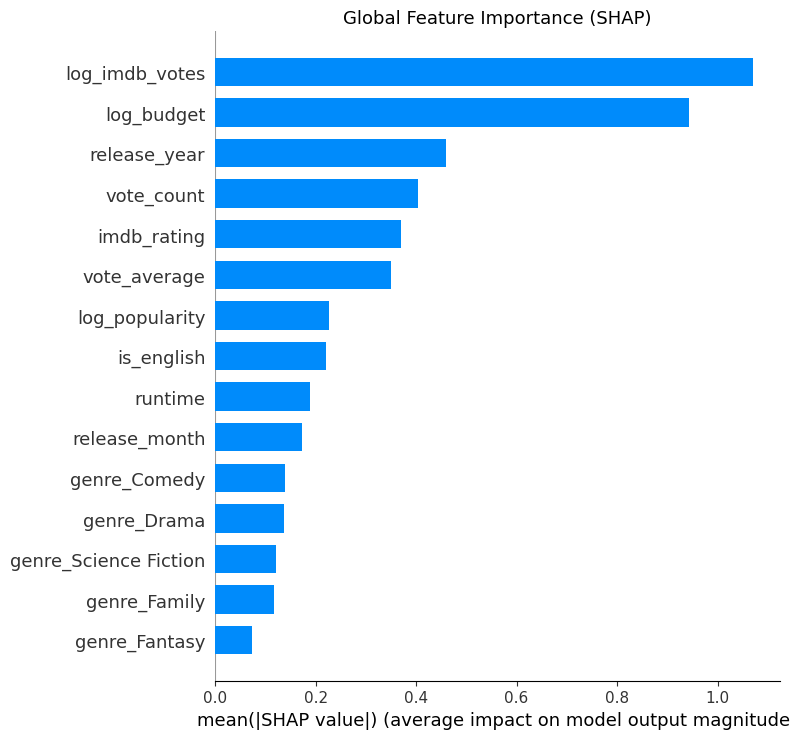

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values, X_test_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig(DRIVE + 'shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

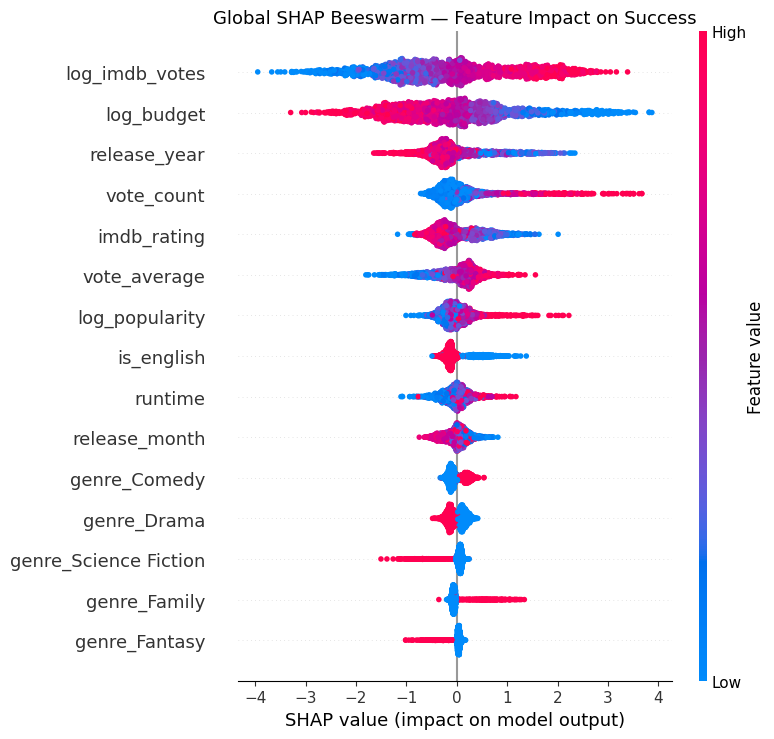

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values, X_test_df,
    max_display=15,
    show=False
)
plt.title('Global SHAP Beeswarm — Feature Impact on Success', fontsize=13)
plt.tight_layout()
plt.savefig(DRIVE + 'shap_global_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
persona_names = {0: 'Blockbusters', 1: 'Indie/Niche', 2: 'Mid-Tier'}
persona_models = {}
persona_shap   = {}

for cluster_id in np.unique(train_clusters):
    name = persona_names[cluster_id]
    print(f"\nTraining SHAP model for: {name}")

    train_mask = train_clusters == cluster_id
    test_mask  = test_clusters  == cluster_id

    X_tr = X_train_df[train_mask]
    y_tr = y_train[train_mask]
    X_te = X_test_df[test_mask]

    model = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0)
    model.fit(X_tr, y_tr)
    persona_models[cluster_id] = model

    exp = shap.TreeExplainer(model)
    sv  = exp.shap_values(X_te)
    persona_shap[cluster_id] = (sv, X_te)

    print(f"  {name}: {len(X_te)} test samples, SHAP computed")


Training SHAP model for: Blockbusters
  Blockbusters: 1175 test samples, SHAP computed

Training SHAP model for: Indie/Niche
  Indie/Niche: 175 test samples, SHAP computed

Training SHAP model for: Mid-Tier
  Mid-Tier: 949 test samples, SHAP computed


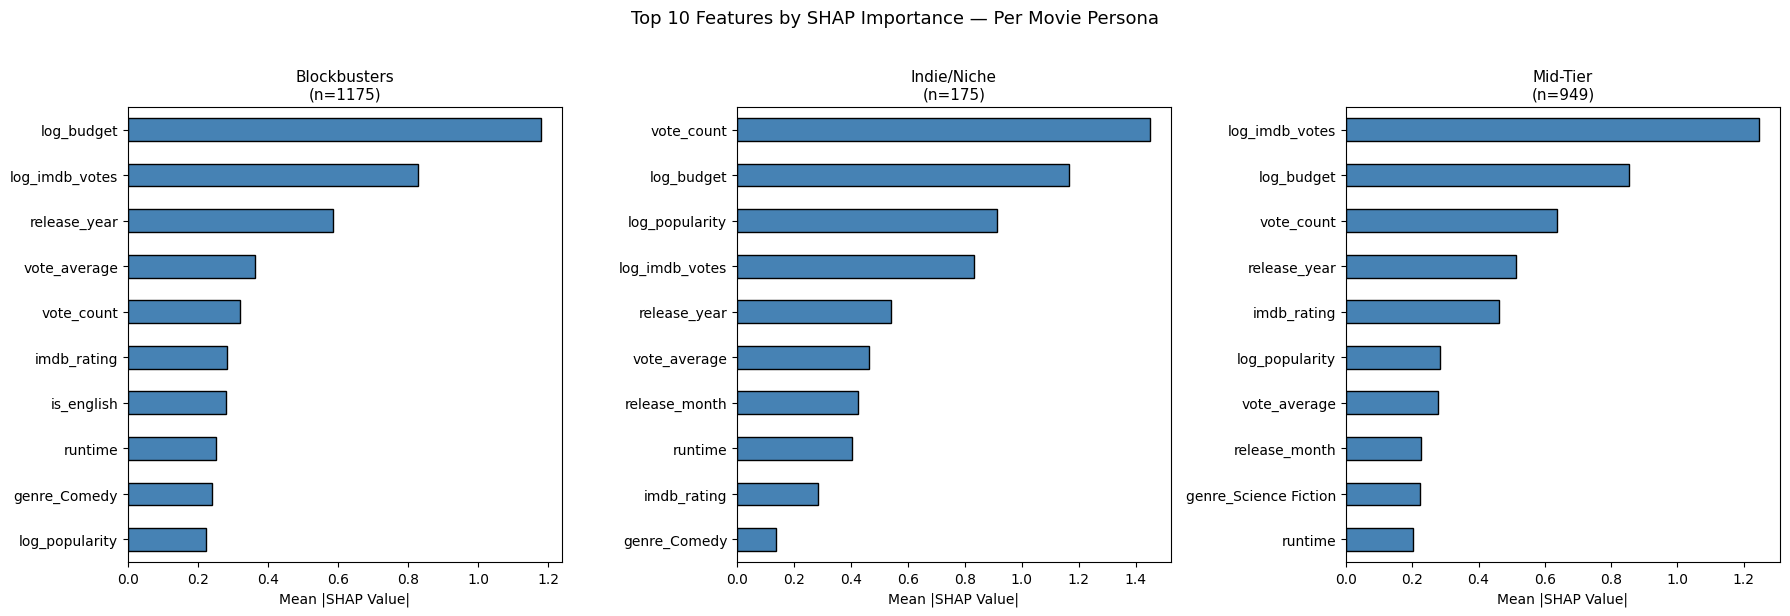

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (cluster_id, (sv, X_te)) in zip(axes, persona_shap.items()):
    name = persona_names[cluster_id]

    mean_shap = np.abs(sv).mean(axis=0)
    shap_series = pd.Series(mean_shap, index=feature_names).sort_values(ascending=True).tail(10)

    shap_series.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{name}\n(n={len(X_te)})', fontsize=11)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_ylabel('')

plt.suptitle('Top 10 Features by SHAP Importance — Per Movie Persona',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DRIVE + 'shap_per_persona.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("Top 5 Most Important Features Per Persona (by mean |SHAP|):\n")
print(f"{'Feature':<30} {'Blockbusters':>15} {'Indie/Niche':>15} {'Mid-Tier':>15}")
print("-" * 75)

importance_dict = {}
for cluster_id, (sv, X_te) in persona_shap.items():
    mean_shap = np.abs(sv).mean(axis=0)
    importance_dict[cluster_id] = pd.Series(mean_shap, index=feature_names)

top_features = set()
for cluster_id in persona_shap:
    top5 = importance_dict[cluster_id].nlargest(5).index.tolist()
    top_features.update(top5)

for feat in sorted(top_features):
    vals = [importance_dict[c].get(feat, 0) for c in [0, 1, 2]]
    print(f"{feat:<30} {vals[0]:>15.4f} {vals[1]:>15.4f} {vals[2]:>15.4f}")


Top 5 Most Important Features Per Persona (by mean |SHAP|):

Feature                           Blockbusters     Indie/Niche        Mid-Tier
---------------------------------------------------------------------------
imdb_rating                             0.2833          0.2831          0.4614
log_budget                              1.1804          1.1649          0.8529
log_imdb_votes                          0.8287          0.8308          1.2474
log_popularity                          0.2222          0.9132          0.2829
release_year                            0.5863          0.5417          0.5146
vote_average                            0.3620          0.4628          0.2763
vote_count                              0.3209          1.4509          0.6380


/tmp/ipykernel_2515/3422446779.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


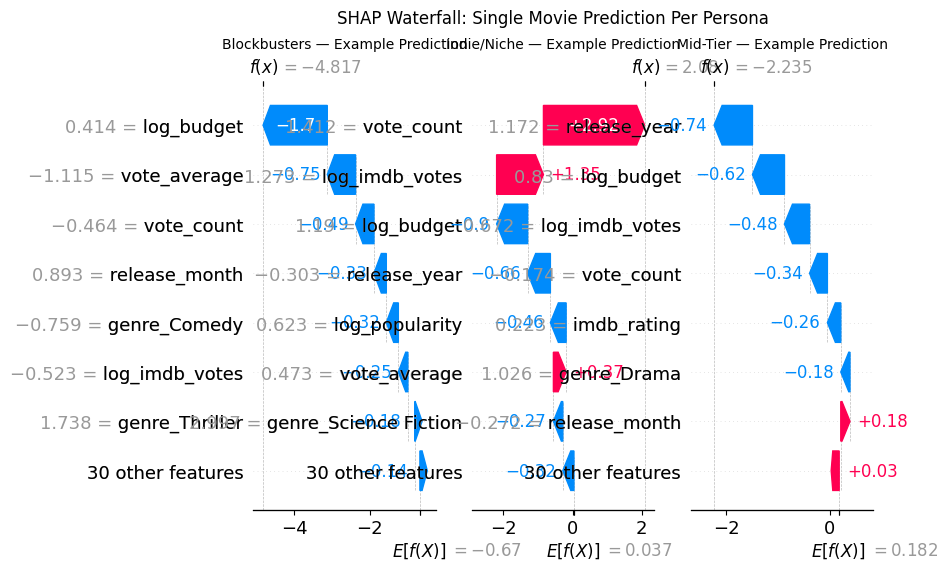

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (cluster_id, (sv, X_te)) in enumerate(persona_shap.items()):
    name = persona_names[cluster_id]
    exp  = shap.TreeExplainer(persona_models[cluster_id])

    sample = X_te.iloc[[0]]
    shap_exp = exp(sample)

    plt.sca(axes[idx])
    shap.plots.waterfall(shap_exp[0], max_display=8, show=False)
    axes[idx].set_title(f'{name} — Example Prediction', fontsize=10)

plt.suptitle('SHAP Waterfall: Single Movie Prediction Per Persona',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DRIVE + 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

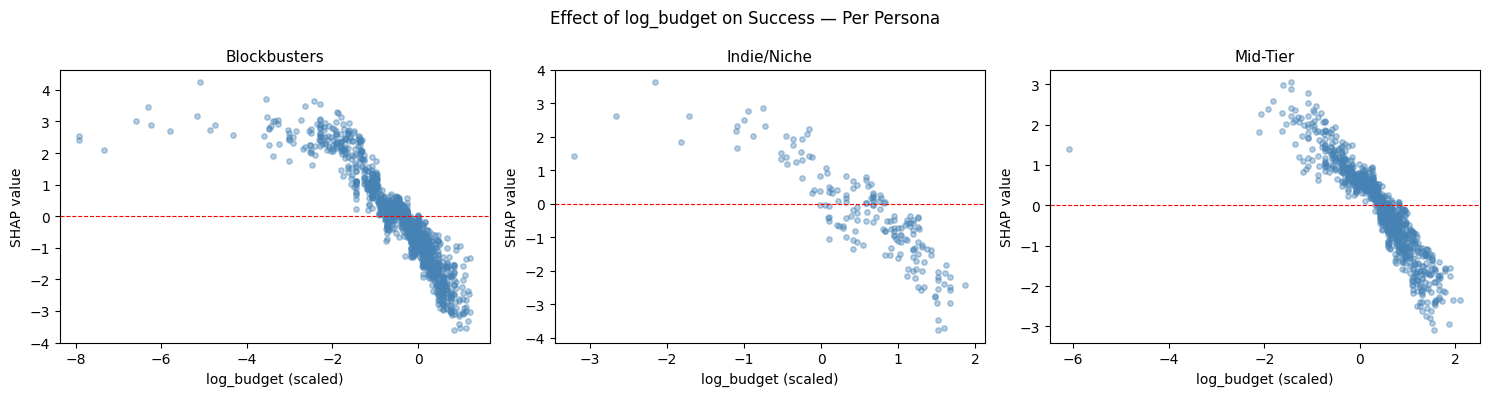

In [ ]:
feature_to_compare = 'log_budget'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (cluster_id, (sv, X_te)) in zip(axes, persona_shap.items()):
    name = persona_names[cluster_id]

    if feature_to_compare in feature_names:
        feat_idx = feature_names.index(feature_to_compare)
        feat_vals  = X_te[feature_to_compare].values
        shap_vals  = sv[:, feat_idx]

        ax.scatter(feat_vals, shap_vals, alpha=0.4, s=15, color='steelblue')
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax.set_title(f'{name}', fontsize=11)
        ax.set_xlabel(f'{feature_to_compare} (scaled)')
        ax.set_ylabel('SHAP value')

plt.suptitle(f'Effect of {feature_to_compare} on Success — Per Persona',
             fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE + 'shap_budget_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
global_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

global_importance.to_csv(DRIVE + 'shap_global_importance.csv', header=['mean_shap'])

for cluster_id, (sv, X_te) in persona_shap.items():
    name = persona_names[cluster_id].replace('/', '_')
    imp = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).sort_values(ascending=False)
    imp.to_csv(DRIVE + f'shap_importance_{name}.csv', header=['mean_shap'])

print("Top 10 global features:")
print(global_importance.head(10).round(4).to_string())

Top 10 global features:
log_imdb_votes    1.0707
log_budget        0.9433
release_year      0.4597
vote_count        0.4030
imdb_rating       0.3696
vote_average      0.3505
log_popularity    0.2267
is_english        0.2205
runtime           0.1896
release_month     0.1721
